**American Express Credit Default Prediction**

Student: Linah Taha

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns #plot visulization built on top of matplotlib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

SEED=42
np.random.seed(SEED)


In [59]:
import os
os.getcwd()

'C:\\Users\\linah\\anaconda_projects\\8a74cc54-cb50-4a9a-92e8-eec9eb12df52'

In [60]:
#Load Subset of training Data 
data=pd.read_csv('train_data.csv', nrows=50000) #w/o loading the file in juprter 
labels=pd.read_csv('train_labels.csv')

print(f'shape of raw:{data.shape}')
print(f'Labels shape: {labels.shape}')
data.head()


shape of raw:(50000, 190)
Labels shape: (458913, 2)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827


Unique customers : 4,154
Avg statements   : 12.0
target
0    3035
1    1119
Name: count, dtype: int64
Default rate: 26.9%


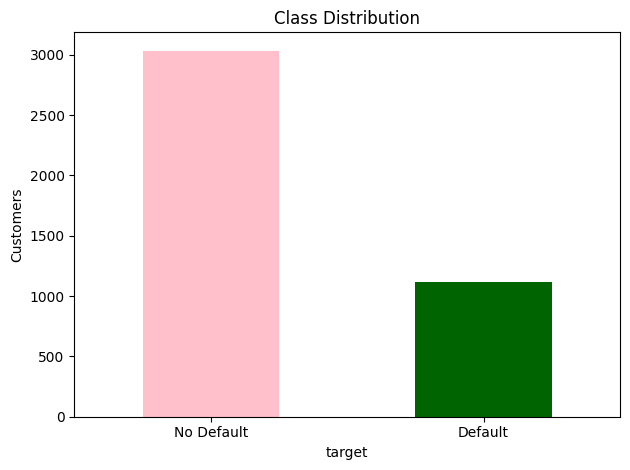

In [61]:
sampled_ids = data['customer_ID'].unique()
print(f'Unique customers : {len(sampled_ids):,}')
print(f'Avg statements   : {len(data)/len(sampled_ids):.1f}')

labels_sample = labels[labels['customer_ID'].isin(sampled_ids)].copy()
counts = labels_sample['target'].value_counts()
print(counts)
print(f'Default rate: {counts[1]/counts.sum():.1%}')

counts.plot(kind='bar', color=['pink', 'darkgreen'])
plt.xticks([0,1], ['No Default','Default'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

**Missing Values across all columns**

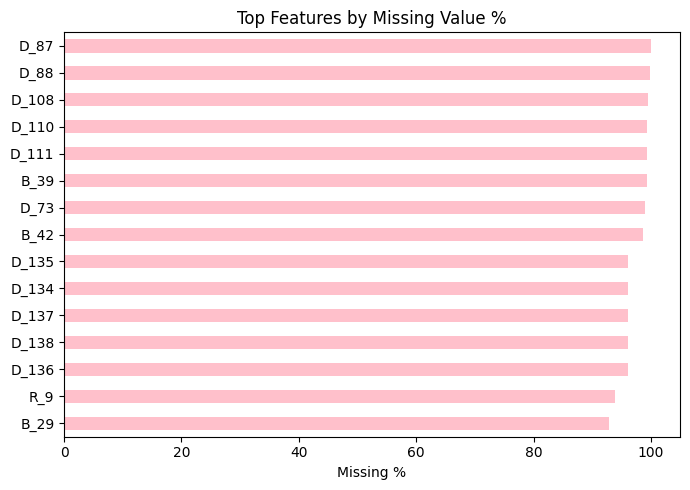

In [62]:
missing=(data.isnull().sum()/len(data)*100).sort_values(ascending=False)
missing[missing>0].head(15).plot(kind="barh", color="pink", figsize=(7,5))
plt.title('Top Features by Missing Value %')
plt.xlabel('Missing %')
plt.tight_layout()
plt.gca().invert_yaxis() #highest on top
plt.show()

**Feature Engineering**
Based on Kaggel Data Explorer 'train_data.csv' it is evident that each customer can have multiple rows per monthly statement. However 'train_labels.csv' has one label per customer

In [63]:
#Aggregate=customers multiple rows into one 

#seprate features from Id,and date  
ignore=['customer_ID', 'S_2']

#categorical columns given by kaggel->mode
catg_cols=['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']

#remaing from 190 = numrical->mean, std
catg=[c for c in catg_cols if c in data.columns]
num=[c for c in data.columns if c not in catg_cols + ['customer_ID','S_2'] ]

print(f'Numeric features    : {len(num)}')
print(f'Categorical features: {len(catg)}')



Numeric features    : 177
Categorical features: 11


In [64]:
# Aggregate numeric features -> mean, std, last per customer
num_agg = data.groupby('customer_ID')[num].agg(['mean','std','last'])
num_agg.columns = ['_'.join(c) for c in num_agg.columns]

# Aggregate categorical features-> most frequent value
def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

cat_agg = data.groupby('customer_ID')[catg].agg(safe_mode)
cat_agg.columns = [f'{c}_mode' for c in cat_agg.columns]

agg = pd.concat([num_agg, cat_agg], axis=1).reset_index()

#New Feature 1: last - mean
for col in num:
    if f'{col}_last' in agg.columns and f'{col}_mean' in agg.columns:
        agg[f'{col}_trend'] = agg[f'{col}_last'] - agg[f'{col}_mean']

#New Feature 2: _std columns = volatility from aggregation

print(f'Feature matrix: {agg.shape}')
agg.head()

Feature matrix: (4154, 720)


,customer_ID,P_2_mean,P_2_std,P_2_last,D_39_mean,D_39_std,D_39_last,B_1_mean,B_1_std,B_1_last,...,D_136_trend,D_137_trend,D_138_trend,D_139_trend,D_140_trend,D_141_trend,D_142_trend,D_143_trend,D_144_trend,D_145_trend
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.934745,0.010704,0.024444,0.009119,0.012007,0.006547,0.009382,...,NaN,NaN,NaN,0.003523,-0.001108,-0.000092,NaN,0.000744,-0.002313,0.002719
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.880519,0.215205,0.199150,0.178126,0.025654,0.027756,0.034684,...,NaN,NaN,NaN,-0.001925,0.001208,0.001863,NaN,-0.001540,-0.001049,0.003612
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.880875,0.004181,0.002758,0.009704,0.004386,0.002786,0.004284,...,NaN,NaN,NaN,0.001378,0.001947,-0.002642,NaN,-0.002086,-0.004280,-0.001055
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.621776,0.048862,0.088466,0.001083,0.059876,0.080531,0.012564,...,NaN,NaN,NaN,-0.003070,0.000407,-0.002283,NaN,0.001440,0.000792,-0.002252
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.871900,0.004644,0.002882,0.005573,0.005941,0.002475,0.007679,...,NaN,NaN,NaN,-0.000879,-0.000656,0.000946,NaN,0.003301,0.002564,-0.003314


In [65]:

df = agg.merge(labels_sample, on='customer_ID', how='inner')

for col in [c for c in df.columns if c.endswith('_mode')]:
    df[col] = pd.Categorical(df[col]).codes

X = df.drop(columns=['customer_ID','target'])
y = df['target']

# Fill missing values with median
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Scale/ fit on train, avoid data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (3323, 719) | Test: (831, 719)


**Model 1: Logistic Regression**

In [66]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_sc, y_train)

lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:,1]

print(classification_report(y_test, lr_pred, target_names=['No Default','Default']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}')

              precision    recall  f1-score   support

  No Default       0.90      0.88      0.89       607
     Default       0.70      0.74      0.72       224

    accuracy                           0.84       831
   macro avg       0.80      0.81      0.81       831
weighted avg       0.85      0.84      0.85       831

ROC-AUC: 0.8895


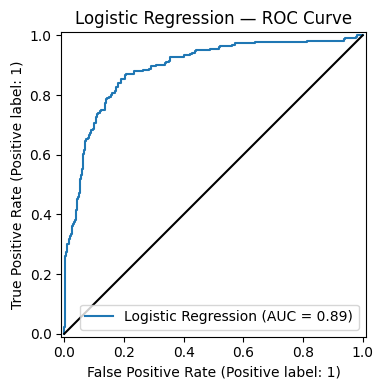

In [67]:
fig, ax = plt.subplots(figsize=(6,4))
RocCurveDisplay.from_predictions(y_test, lr_proba, ax=ax, name='Logistic Regression')
ax.plot([0,1],[0,1],'k')
ax.set_title('Logistic Regression — ROC Curve')
plt.tight_layout()
plt.show()

**Model 2: Random Forest**

In [68]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced',
                             random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred, target_names=['No Default','Default']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}')

              precision    recall  f1-score   support

  No Default       0.95      0.84      0.89       607
     Default       0.67      0.88      0.76       224

    accuracy                           0.85       831
   macro avg       0.81      0.86      0.83       831
weighted avg       0.87      0.85      0.86       831

ROC-AUC: 0.9395


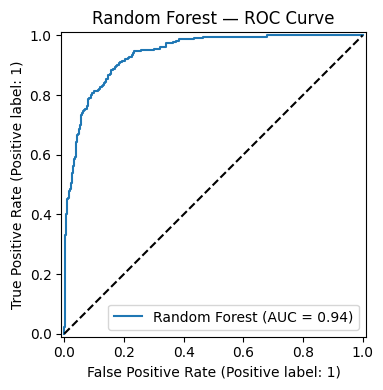

In [69]:
fig, ax = plt.subplots(figsize=(5,4))

RocCurveDisplay.from_predictions(y_test, rf_proba, ax=ax, name='Random Forest')
ax.plot([0,1],[0,1],'k--')
ax.set_title('Random Forest — ROC Curve')

plt.tight_layout()
plt.show()


**Advanced Model: XGBoost**

In [70]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_weight = {spw:.2f}')

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                     scale_pos_weight=spw, random_state=SEED, n_jobs=-1,
                     eval_metric='auc', verbosity=0)
xgb.fit(X_train, y_train)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, xgb_pred, target_names=['No Default','Default']))
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')

scale_weight = 2.71
              precision    recall  f1-score   support

  No Default       0.94      0.88      0.91       607
     Default       0.73      0.84      0.78       224

    accuracy                           0.87       831
   macro avg       0.83      0.86      0.84       831
weighted avg       0.88      0.87      0.87       831

ROC-AUC: 0.9431


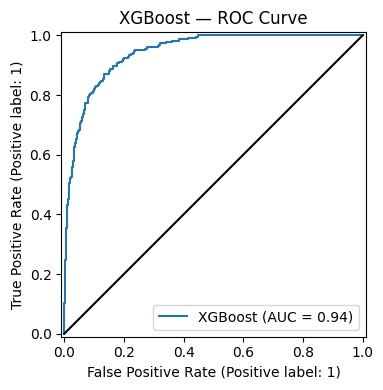

In [71]:
fig, ax = plt.subplots(figsize=(5,4))

RocCurveDisplay.from_predictions(y_test, xgb_proba, ax=ax, name='XGBoost')
ax.plot([0,1],[0,1],'k')
ax.set_title('XGBoost — ROC Curve')

plt.tight_layout()
plt.show()


**Model comparison**

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

summary = pd.DataFrame([
    {'Model': name,
     'Accuracy' : round(accuracy_score(y_test, pred), 3),
     'Precision': round(precision_score(y_test, pred), 3),
     'Recall'   : round(recall_score(y_test, pred), 3),
     'F1'       : round(f1_score(y_test, pred), 3),
     'ROC-AUC'  : round(roc_auc_score(y_test, proba), 3)}
    for name, pred, proba in [
        ('Logistic Regression', lr_pred,  lr_proba),
        ('Random Forest',       rf_pred,  rf_proba),
        ('XGBoost',             xgb_pred, xgb_proba)]
])
print(summary.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.844      0.697   0.741 0.719    0.889
      Random Forest     0.850      0.667   0.884 0.760    0.940
            XGBoost     0.871      0.726   0.839 0.778    0.943


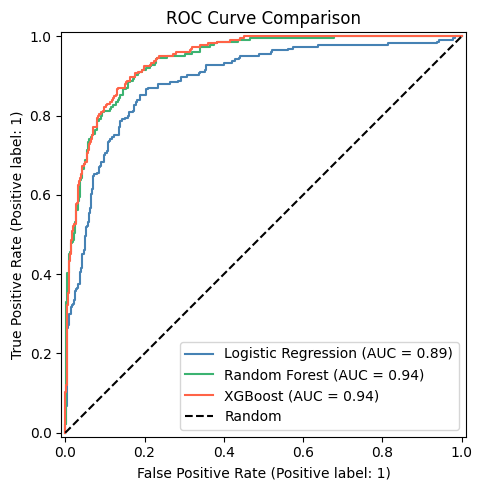

In [73]:
fig, ax = plt.subplots(figsize=(6,5))
for name, proba, color in [
    ('Logistic Regression', lr_proba,  'steelblue'),
    ('Random Forest',       rf_proba,  'mediumseagreen'),
    ('XGBoost',             xgb_proba, 'tomato')]:
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name, color=color)
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:**
Feature Engineering: 'trend' is the last value minus the mean and 'std' is the valility through the statemnt. These two features allow us to see if the behavior of the customer id decreasing.

Results: 
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.844      0.697   0.741 0.719    0.889
      Random Forest     0.850      0.667   0.884 0.760    0.940
            XGBoost     0.871      0.726   0.839 0.778    0.943

XGBosst is the best ranked ROC-Auc of 0.943, meaning it is the best overall at predicting who would default. While Random Forest achived a recall of 0.884, important concidering the imbalance of classes. 
